In [1]:
import numpy as np
import pandas as pd

In [2]:
import numpy as np

X_train = np.load(r'/content/ModelingReady_X_train.npy', allow_pickle=True)
X_val   = np.load(r'/content/ModelingReady_X_val.npy', allow_pickle=True)

y_train = np.load(r'/content/ModelingReady_y_train.npy', allow_pickle=True)
y_val   = np.load(r'/content/ModelingReady_y_val.npy', allow_pickle=True)


In [3]:
import joblib
tokenizer = joblib.load('/content/input_tokenizer.pkl')

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train =  pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=40,  # covers 99% of your data with minimal padding waste
    padding='post',
    truncating='post'
)

X_val =  pad_sequences(
    tokenizer.texts_to_sequences(X_val),
    maxlen=40,  # covers 99% of your data with minimal padding waste
    padding='post',
    truncating='post'
)

# X_test =  pad_sequences(
#     tokenizer.texts_to_sequences(X_test),
#     maxlen=40,  # covers 99% of your data with minimal padding waste
#     padding='post',
#     truncating='post'
# )

## Models for Comparison

This project compares four architectures for financial text sentiment classification, forming a progression from simple recurrence to attention-based encoding. Each model uses the same tokenized/padded input and pretrained embedding matrix (Word2Vec, with FastText as a secondary comparison), so differences in performance can be attributed to the architecture itself.

### Model A — Simple RNN (Baseline)
A plain recurrent neural network processes the input sequence step-by-step. Serves as the baseline / performance floor, since vanilla RNNs are known to struggle with longer-range dependencies due to vanishing gradients.

### Model B — LSTM
Adds gating mechanisms (input, forget, output gates) to address the vanishing gradient problem, allowing the model to retain relevant information over longer sequences.

### Model C — GRU
A lighter alternative to LSTM using fewer gates (reset, update), often achieving comparable performance with fewer parameters and faster training.

### Model D — Transformer Encoder (Self-Attention)
Replaces recurrence entirely with self-attention, allowing the model to weigh relationships between all tokens in the sequence simultaneously rather than sequentially. Tests whether attention-based encoding outperforms gated recurrence for this classification task.

### Comparison Goal
By holding the embedding, data, and training setup constant across all four models, this comparison isolates the effect of architecture choice alone — answering: *does moving from simple recurrence → gated recurrence → self-attention meaningfully improve financial sentiment classification performance?*

# Baseline model - Simple RNN

In [6]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.4 MB/s eta 0:00:00


In [7]:
import tensorflow as tf
import tensorflow.keras as keras
from keras.layers import *
from keras.models import Model
import keras_tuner as kt

In [8]:
word2vec_weights = np.load(r'/content/word2vec_input_embedding_matrix.npy')

In [12]:

inp = Input(shape=(40,), name="Input")

embedding = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=300,
    weights=[word2vec_weights],
    trainable=True,
    mask_zero=True,
    name="Embedding"
)(inp)

# using 3 stacked BiRNN layers
rnn1 = Bidirectional(SimpleRNN(units=256, return_sequences=True), name='BiRNN_1')(embedding)
rnn2 = Bidirectional(SimpleRNN(units=128, return_sequences=True), name='BiRNN_2')(rnn1)
rnn3 = Bidirectional(SimpleRNN(units=64, return_sequences=False), name='BiRNN_3')(rnn2)

# Output
output_layer = Dense(units=3, activation='softmax', name='Output')(rnn3)

model_rnn = Model(inputs=inp, outputs=output_layer, name='SimpleRNN_Baseline')
model_rnn.summary()

Model: "SimpleRNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_1             │ (None, 40, 512)   │    285,184 │ Embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_2             │ (None, 40, 256)   │    164,096 │ BiRNN_1[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_3             │ (None, 128)       │     41,088 │ BiRNN_2[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │        387 │ BiRNN_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,046,255 (19.25 MB)

 Trainable params: 5,046,255 (19.25 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',   # labels are integers (0/1/2), not one-hot
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/rnn_model_epoch_{epoch:02d}_val_loss_{val_loss:.4f}.keras',
    monitor='val_loss',
    save_best_only=False,
    verbose=1
)


history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6506 - loss: 0.8361
Epoch 1: saving model to /content/Model_saved/rnn_model_epoch_01_val_loss_0.6119.keras

Epoch 1: finished saving model to /content/Model_saved/rnn_model_epoch_01_val_loss_0.6119.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.7046 - loss: 0.7204 - val_accuracy: 0.7439 - val_loss: 0.6119
Epoch 2/20
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8691 - loss: 0.3530
Epoch 2: saving model to /content/Model_saved/rnn_model_epoch_02_val_loss_0.6357.keras

Epoch 2: finished saving model to /content/Model_saved/rnn_model_epoch_02_val_loss_0.6357.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8655 - loss: 0.3602 - val_accuracy: 0.7816 - val_loss: 0.6357
Epoch 3/20
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9237 - loss: 0.2172
Epoch 3: saving model to /content/Model_saved/rnn_model_epoch_03_val_loss_0.8147.keras

Epoch 3: finished saving model to /content/Mod

In [16]:
pd.DataFrame(history_rnn.history)

,accuracy,loss,val_accuracy,val_loss
0,0.704604,0.720410,0.743924,0.611891
1,0.865516,0.360243,0.781613,0.635741
2,0.926122,0.203766,0.731243,0.814728
3,0.978036,0.069947,0.777386,0.914680


In [19]:
import tensorflow as tf

# Replace with the exact filename you want to load
model = tf.keras.models.load_model('/content/Model_saved/rnn_model_epoch_01_val_loss_0.6119.keras')

# Verify the model structure
model.summary()
joblib.dump(model, 'RNN_baseline.pkl')

Model: "SimpleRNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_1             │ (None, 40, 512)   │    285,184 │ Embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_2             │ (None, 40, 256)   │    164,096 │ BiRNN_1[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_3             │ (None, 128)       │     41,088 │ BiRNN_2[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │        387 │ BiRNN_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,138,767 (57.75 MB)

 Trainable params: 5,046,255 (19.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,092,512 (38.50 MB)

['RNN_baseline.pkl']

## it is overfitting applying dropout

In [ ]:

inp = Input(shape=(40,), name="Input")

embedding = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=300,
    weights=[word2vec_weights],
    trainable=True,
    mask_zero=True,
    name="Embedding"
)(inp)

# using 3 stacked BiRNN layers
rnn1 = Bidirectional(SimpleRNN(units=256, return_sequences=True,dropout=0.2, recurrent_dropout=0.3), name='BiRNN_1')(embedding)
rnn2 = Bidirectional(SimpleRNN(units=128, return_sequences=True,dropout=0.15, recurrent_dropout=0.2), name='BiRNN_2')(rnn1)
rnn3 = Bidirectional(SimpleRNN(units=64, return_sequences=False,dropout=0.1, recurrent_dropout=0.1), name='BiRNN_3')(rnn2)

# Output
output_layer = Dense(units=3, activation='softmax', name='Output')(rnn3)

model_rnn = Model(inputs=inp, outputs=output_layer, name='SimpleRNN_Baseline')
model_rnn.summary()

Model: "SimpleRNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_1             │ (None, 40, 512)   │    285,184 │ Embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_2             │ (None, 40, 256)   │    164,096 │ BiRNN_1[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_3             │ (None, 128)       │     41,088 │ BiRNN_2[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │        387 │ BiRNN_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,046,255 (19.25 MB)

 Trainable params: 5,046,255 (19.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',   # labels are integers (0/1/2), not one-hot
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/best_rnn_model2.keras', monitor='val_loss', save_best_only=True
)

history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 35s 125ms/step - accuracy: 0.6537 - loss: 0.8375 - val_accuracy: 0.7274 - val_loss: 0.7052
Epoch 2/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7425 - loss: 0.6338 - val_accuracy: 0.7432 - val_loss: 0.6598
Epoch 3/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8042 - loss: 0.5018 - val_accuracy: 0.7696 - val_loss: 0.6965
Epoch 4/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8538 - loss: 0.3788 - val_accuracy: 0.7658 - val_loss: 0.7207
Epoch 5/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.8973 - loss: 0.2740 - val_accuracy: 0.7675 - val_loss: 0.7695


## Redcuing neurons + increasing batch size

In [ ]:

inp = Input(shape=(40,), name="Input")

embedding = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=300,
    weights=[word2vec_weights],
    trainable=True,
    mask_zero=True,
    name="Embedding"
)(inp)

# using 3 stacked BiRNN layers
rnn1 = Bidirectional(SimpleRNN(units=128, return_sequences=True,dropout=0.2, recurrent_dropout=0.3), name='BiRNN_1')(embedding)
rnn2 = Bidirectional(SimpleRNN(units=96, return_sequences=True,dropout=0.15, recurrent_dropout=0.2), name='BiRNN_2')(rnn1)
rnn3 = Bidirectional(SimpleRNN(units=64, return_sequences=False,dropout=0.1, recurrent_dropout=0.1), name='BiRNN_3')(rnn2)

# Output
output_layer = Dense(units=3, activation='softmax', name='Output')(rnn3)

model_rnn = Model(inputs=inp, outputs=output_layer, name='SimpleRNN_Baseline')
model_rnn.summary()

Model: "SimpleRNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_1             │ (None, 40, 256)   │    109,824 │ Embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_2             │ (None, 40, 192)   │     67,776 │ BiRNN_1[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiRNN_3             │ (None, 128)       │     32,896 │ BiRNN_2[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │        387 │ BiRNN_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,766,383 (18.18 MB)

 Trainable params: 4,766,383 (18.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',   # labels are integers (0/1/2), not one-hot
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/best_rnn_model3.keras', monitor='val_loss', save_best_only=True
)

history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=96,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 37s 193ms/step - accuracy: 0.6432 - loss: 0.8635 - val_accuracy: 0.7179 - val_loss: 0.7256
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7355 - loss: 0.6445 - val_accuracy: 0.7386 - val_loss: 0.6839
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7844 - loss: 0.5331 - val_accuracy: 0.7415 - val_loss: 0.6934
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8358 - loss: 0.4235 - val_accuracy: 0.7563 - val_loss: 0.7136
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8798 - loss: 0.3186 - val_accuracy: 0.7767 - val_loss: 0.7242


## Model A: Simple RNN (Baseline) — Results & Analysis

### Architecture
Bidirectional SimpleRNN, stacked layers, Word2Vec pretrained embeddings (300-dim), trained with dropout and early stopping.

### Training Runs

**Run 1 — Initial (256→128→64 units, no dropout, 3 layers)**

| Epoch | Train Acc | Train Loss | Val Acc | Val Loss |
|---|---|---|---|---|
| 1 | 70.7% | 0.7315 | 75.3% | 0.6089 |
| 2 | 85.9% | 0.3747 | 76.4% | 0.6618 |
| 3 | 92.8% | 0.2045 | 77.2% | 0.7393 |
| 4 | 97.8% | 0.0714 | 77.6% | 0.9172 |

Severe overfitting from epoch 2 onward — train accuracy shoots toward 98% while val loss climbs steadily after epoch 1.

**Run 2 — Added dropout + recurrent_dropout**

| Epoch | Train Acc | Train Loss | Val Acc | Val Loss |
|---|---|---|---|---|
| 1 | 65.4% | 0.8375 | 72.7% | 0.7052 |
| 2 | 74.3% | 0.6338 | 74.3% | **0.6598** ← best |
| 3 | 80.4% | 0.5018 | 77.0% | 0.6965 |
| 4 | 85.4% | 0.3788 | 76.6% | 0.7207 |
| 5 | 89.7% | 0.2740 | 76.8% | 0.7695 |

Dropout delayed overfitting slightly and improved best val_loss marginally (0.66 vs 0.61 raw, but with a healthier train/val gap at that point). Overfitting still visible from epoch 3 onward.

**Run 3 — Reduced units + increased batch size**

| Epoch | Train Acc | Train Loss | Val Acc | Val Loss |
|---|---|---|---|---|
| 1 | 64.3% | 0.8635 | 71.8% | 0.7256 |
| 2 | 73.6% | 0.6445 | 73.9% | **0.6839** ← best |
| 3 | 78.4% | 0.5331 | 74.2% | 0.6934 |
| 4 | 83.6% | 0.4235 | 75.6% | 0.7136 |
| 5 | 88.0% | 0.3186 | 77.7% | 0.7242 |

Similar overfitting pattern despite reduced model capacity and larger batch size — confirms the ceiling isn't a capacity/batch-size issue.

### Conclusion
Across three variations (dropout, regularization, capacity/batch tuning), the SimpleRNN baseline consistently:
- Peaks at **~74-78% validation accuracy**
- Best **validation loss ≈ 0.66-0.68**, occurring around **epoch 2**
- Overfits rapidly afterward regardless of regularization strategy tried

This converges on a **stable ceiling for a plain (ungated) RNN architecture** on this dataset — further hyperparameter tuning shows diminishing returns. This is treated as the final baseline result (Model A), preserved automatically via `EarlyStopping(restore_best_weights=True)`.

**Final Model A benchmark: ~74–77% val accuracy, ~0.66–0.68 val loss**

### Why Move to LSTM Next
SimpleRNN's rapid overfitting and accuracy plateau is consistent with its known limitation: the **vanishing gradient problem**, which makes it difficult for plain recurrence to retain and utilize information across longer token sequences without over-relying on recent/local patterns (a form of memorization rather than generalization).

**Hypothesis for Model B (LSTM)**: The gating mechanism (input, forget, output gates) should allow the model to:
- Retain relevant long-range context more effectively
- Show a slower, more gradual overfitting curve
- Achieve a higher validation accuracy ceiling than the RNN baseline

This directly tests the core comparison this project is built around — whether gated recurrence provides a measurable improvement over plain recurrence for financial sentiment classification.

# LSTM

In [ ]:
# First training a LSTM for overfitting

inp = Input(shape=(40,), name="Input")

embedding = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=300,
    weights=[word2vec_weights],
    trainable=True,
    mask_zero=True,
    name="Embedding"
)(inp)

# using 3 stacked BiRNN layers
lstm1 = Bidirectional(LSTM(units=128, return_sequences=True,use_cudnn=False), name='LSTM_1')(embedding)
lstm2 = Bidirectional(LSTM(units=64, return_sequences=True,use_cudnn=False), name='LSTM_2')(lstm1)
lstm3 = Bidirectional(LSTM(units=32, return_sequences=False,use_cudnn=False), name='LSTM_3')(lstm2)

# Output
output_layer = Dense(units=3, activation='softmax', name='Output')(lstm3)

model_lstm = Model(inputs=inp, outputs=output_layer, name='lstm')
model_lstm.summary()

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_1              │ (None, 40, 256)   │    439,296 │ Embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_2              │ (None, 40, 128)   │    164,352 │ LSTM_1[0][0],     │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_3              │ (None, 64)        │     41,216 │ LSTM_2[0][0],     │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │        195 │ LSTM_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,200,559 (19.84 MB)

 Trainable params: 5,200,559 (19.84 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',   # labels are integers (0/1/2), not one-hot
    metrics=['accuracy']
)

e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

ck = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/best_lstm_model.keras', monitor='val_accuracy', save_best_only=True
)



history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=20,
    callbacks=[e1,e2,ck]
)

Epoch 1/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 90s 571ms/step - accuracy: 0.7353 - loss: 0.6713 - val_accuracy: 0.7830 - val_loss: 0.5618
Epoch 2/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 76s 548ms/step - accuracy: 0.8681 - loss: 0.3512 - val_accuracy: 0.8123 - val_loss: 0.5146
Epoch 3/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 73s 544ms/step - accuracy: 0.9439 - loss: 0.1697 - val_accuracy: 0.8098 - val_loss: 0.5980
Epoch 4/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 73s 545ms/step - accuracy: 0.9739 - loss: 0.0834 - val_accuracy: 0.8070 - val_loss: 0.7434
Epoch 5/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 72s 532ms/step - accuracy: 0.9871 - loss: 0.0434 - val_accuracy: 0.8020 - val_loss: 0.8190


In [ ]:
# Epoch 1/20
# 134/134 ━━━━━━━━━━━━━━━━━━━━ 90s 571ms/step - accuracy: 0.7353 - loss: 0.6713 - val_accuracy: 0.7830 - val_loss: 0.5618
# Epoch 2/20
# 134/134 ━━━━━━━━━━━━━━━━━━━━ 76s 548ms/step - accuracy: 0.8681 - loss: 0.3512 - val_accuracy: 0.8123 - val_loss: 0.5146
# Epoch 3/20
# 134/134 ━━━━━━━━━━━━━━━━━━━━ 73s 544ms/step - accuracy: 0.9439 - loss: 0.1697 - val_accuracy: 0.8098 - val_loss: 0.5980
# Epoch 4/20
# 134/134 ━━━━━━━━━━━━━━━━━━━━ 73s 545ms/step - accuracy: 0.9739 - loss: 0.0834 - val_accuracy: 0.8070 - val_loss: 0.7434
# Epoch 5/20
# 134/134 ━━━━━━━━━━━━━━━━━━━━ 72s 532ms/step - accuracy: 0.9871 - loss: 0.0434 - val_accuracy: 0.8020 - val_loss: 0.8190

# This training suggests that we have to apply regularization

In [ ]:
def build_model(hp):
    inp = Input(shape=(40,), name="Input")

    embedding = Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=300,
        weights=[word2vec_weights],
        trainable=True,
        mask_zero=True,
        name="Embedding"
    )(inp)

    # Recurrent units
    lstm1_units = hp.Int('Lstm1_units', min_value=64, max_value=128, step=32)
    lstm2_units = hp.Int('Lstm2_units', min_value=32, max_value=64, step=8)
    lstm3_units = hp.Int('Lstm3_units', min_value=8, max_value=32, step=8)

    # recurrent dropout (shared across layers, by design)
    rec_drop = hp.Choice('Rec_dropout', [0.1, 0.2, 0.3,0.4])

    # input dropouts — unique per layer
    lstm1_dropout = hp.Choice('lstm1_input_dropout', [0.1, 0.2, 0.3, 0.4])
    lstm2_dropout = hp.Choice('lstm2_input_dropout', [0.1, 0.2])
    lstm3_dropout = 0.1  # fixed, not worth tuning as a single-value choice

    lstm1 = Bidirectional(
        LSTM(units=lstm1_units, return_sequences=True, use_cudnn=False,
             dropout=lstm1_dropout, recurrent_dropout=rec_drop),
        name='LSTM_1'
    )(embedding)

    ln1 = LayerNormalization()(lstm1)

    lstm2 = Bidirectional(
        LSTM(units=lstm2_units, return_sequences=True, use_cudnn=False,
             dropout=lstm2_dropout, recurrent_dropout=rec_drop),
        name='LSTM_2'
    )(ln1)

    ln2 = LayerNormalization()(lstm2)

    lstm3 = Bidirectional(
        LSTM(units=lstm3_units, return_sequences=False, use_cudnn=False,
             dropout=lstm3_dropout, recurrent_dropout=rec_drop),
        name='LSTM_3'
    )(ln2)

    #  output
    output_layer = Dense(units=3, activation='softmax', name='Output')(lstm3)

    model_lstm2 = Model(inputs=inp, outputs=output_layer, name='lstm')

    model_lstm2.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model_lstm2

In [ ]:
tuner_lstm = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=6,             # keep small given slow non-cuDNN LSTM training
    executions_per_trial=1,
    directory='tuner_results',
    project_name='lstm_search',
    overwrite=True
)
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

ck = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/best_lstm_model_hp_1.keras', monitor='val_accuracy', save_best_only=True
)

tuner_lstm.search_space_summary()


Search space summary
Default search space size: 7
Lstm1_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
Lstm2_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
Lstm3_units (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 32, 'step': 8, 'sampling': 'linear'}
Rec_dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2, 0.3, 0.4], 'ordered': True}
lstm1_input_dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2, 0.3, 0.4], 'ordered': True}
lstm2_input_dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


In [ ]:
# ================= RUN SEARCH =================

tuner_lstm.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=5,                  # small — search phase only, not final training
    callbacks=[e1,e2]
)

Trial 6 Complete [00h 13m 06s]
val_loss: 0.5459923148155212

Best val_loss So Far: 0.5138009786605835
Total elapsed time: 01h 17m 07s


In [ ]:

Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
64                |64                |Lstm1_units
48                |48                |Lstm2_units
32                |32                |Lstm3_units
0.4               |0.4               |Rec_dropout
0.2               |0.2               |lstm1_input_dropout
0.2               |0.2               |lstm2_input_dropout
0.001             |0.001             |learning_rate


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
64                |64                |Lstm1_units
48                |48                |Lstm2_units
32                |32                |Lstm3_units
0.4               |0.4               |Rec_dropout
0.2               |0.2               |lstm1_input_dropout
0.2               |0.2               |lstm2_input_dropout
0.001             |0.001             |learning_rate

Trial 2 Complete [00h 13m 06s]
val_loss: 0.5548682808876038

Best val_loss So Far: 0.5138009786605835
Total elapsed time: 00h 25m 14s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
96                |64                |Lstm1_units
48                |48                |Lstm2_units
8                 |32                |Lstm3_units
0.1               |0.4               |Rec_dropout
0.1               |0.2               |lstm1_input_dropout
0.2               |0.2               |lstm2_input_dropout
0.0001            |0.001             |learning_rate

Trial 3 Complete [00h 13m 06s]
val_loss: 0.6471838355064392

Best val_loss So Far: 0.5138009786605835
Total elapsed time: 00h 38m 20s

Search: Running Trial #4

Value             |Best Value So Far |Hyperparameter
128               |64                |Lstm1_units
56                |48                |Lstm2_units
24                |32                |Lstm3_units
0.4               |0.4               |Rec_dropout
0.1               |0.2               |lstm1_input_dropout
0.2               |0.2               |lstm2_input_dropout
0.0005            |0.001             |learning_rate

Trial 3 Complete [00h 13m 06s]
val_loss: 0.6471838355064392

Best val_loss So Far: 0.5138009786605835
Total elapsed time: 00h 38m 20s

Search: Running Trial #4

Value             |Best Value So Far |Hyperparameter
128               |64                |Lstm1_units
56                |48                |Lstm2_units
24                |32                |Lstm3_units
0.4               |0.4               |Rec_dropout
0.1               |0.2               |lstm1_input_dropout
0.2               |0.2               |lstm2_input_dropout
0.0005            |0.001             |learning_rate

SyntaxError: invalid decimal literal (1712706755.py, line 24)

In [ ]:
tuner_lstm.get_best_hyperparameters()[0].values

{'Lstm1_units': 64,
 'Lstm2_units': 48,
 'Lstm3_units': 32,
 'Rec_dropout': 0.4,
 'lstm1_input_dropout': 0.2,
 'lstm2_input_dropout': 0.2,
 'learning_rate': 0.001}

In [ ]:
# Tuner best model
from keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, LayerNormalization
from keras.models import Model
from keras.optimizers import Adam

# Input
inp = Input(shape=(40,), name="Input")

# Embedding
embedding = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=300,
    weights=[word2vec_weights],
    trainable=True,
    mask_zero=True,
    name="Embedding"
)(inp)

# LSTM layers with tuned parameters
lstm1 = Bidirectional(
    LSTM(
        units=64,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.4
    ),
    name="LSTM_1"
)(embedding)

ln1 = LayerNormalization()(lstm1)

lstm2 = Bidirectional(
    LSTM(
        units=32,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.4
    ),
    name="LSTM_2"
)(ln1)

ln2 = LayerNormalization()(lstm2)

lstm3 = Bidirectional(
    LSTM(
        units=16,
        return_sequences=False,
        dropout=0.4,          # fixed value
        recurrent_dropout=0.4
    ),
    name="LSTM_3"
)(ln2)

# Output
output_layer = Dense(units=3, activation='softmax', name="Output")(lstm3)

# Build model
model_lstm2 = Model(inputs=inp, outputs=output_layer, name="LSTM_Model")

# Compile
model_lstm2.compile(
    optimizer=Adam(learning_rate=0.0002),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_lstm2.summary()


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_1              │ (None, 40, 128)   │    186,880 │ Embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 128)   │        256 │ LSTM_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_2              │ (None, 40, 64)    │     41,216 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ LSTM_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_3              │ (None, 32)        │     10,368 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │         99 │ LSTM_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,794,447 (18.29 MB)

 Trainable params: 4,794,447 (18.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True,min_delta=0.005
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=2, restore_best_weights=True,min_delta=0.005
)

ck = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/best_final_lstm.keras', monitor='val_accuracy', save_best_only=True,verbose=1
)

model_lstm2.fit(
    X_train, y_train, validation_data = (X_val,y_val)
    ,epochs = 20, callbacks = [e1,e2,ck], batch_size = 128, verbose = 1
)


Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5030 - loss: 1.0226
Epoch 1: val_accuracy improved from None to 0.63931, saving model to /content/Model_saved/best_final_lstm.keras

Epoch 1: finished saving model to /content/Model_saved/best_final_lstm.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5743 - loss: 0.9632 - val_accuracy: 0.6393 - val_loss: 0.9049
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6471 - loss: 0.8696
Epoch 2: val_accuracy improved from 0.63931 to 0.64988, saving model to /content/Model_saved/best_final_lstm.keras

Epoch 2: finished saving model to /content/Model_saved/best_final_lstm.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.6389 - loss: 0.8748 - val_accuracy: 0.6499 - val_loss: 0.8264
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6643 - loss: 0.8241
Epoch 3: val_accuracy improved from 0.64988 to 0.68299, saving model to /content/Model_saved/best_final_lstm.keras

Epoch 3: finished sav

In [ ]:
df_final_lstm_model = pd.DataFrame(model_lstm2.history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.574348,0.963250,0.639310,0.904870
1,0.638948,0.874815,0.649877,0.826388
2,0.666549,0.809893,0.682987,0.753383
3,0.685812,0.754368,0.710814,0.705322
4,0.717524,0.688300,0.729834,0.658831
5,0.734320,0.643488,0.737231,0.653985
6,0.754287,0.605030,0.743572,0.629403
7,0.766972,0.570706,0.749560,0.623884
8,0.789993,0.526908,0.758366,0.617449
9,0.804322,0.495649,0.769285,0.601338


In [ ]:
model_lstm2.evaluate(X_train,y_train)

267/267 ━━━━━━━━━━━━━━━━━━━━ 46s 173ms/step - accuracy: 0.8991 - loss: 0.2767


[0.2766501009464264, 0.8991073369979858]

In [ ]:
model_lstm2.evaluate(X_val,y_val)

89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - accuracy: 0.7922 - loss: 0.5939


[0.5939438343048096, 0.7921803593635559]

In [ ]:
model_lstm2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_1              │ (None, 40, 128)   │    186,880 │ Embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 128)   │        256 │ LSTM_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_2              │ (None, 40, 64)    │     41,216 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ LSTM_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_3              │ (None, 32)        │     10,368 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │         99 │ LSTM_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,383,343 (54.87 MB)

 Trainable params: 4,794,447 (18.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,588,896 (36.58 MB)

In [ ]:
# Saving finalised LSTM model
import joblib

joblib.dump(model_lstm2, 'Final_LSTM_Model.pkl')

['Final_LSTM_Model.pkl']

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

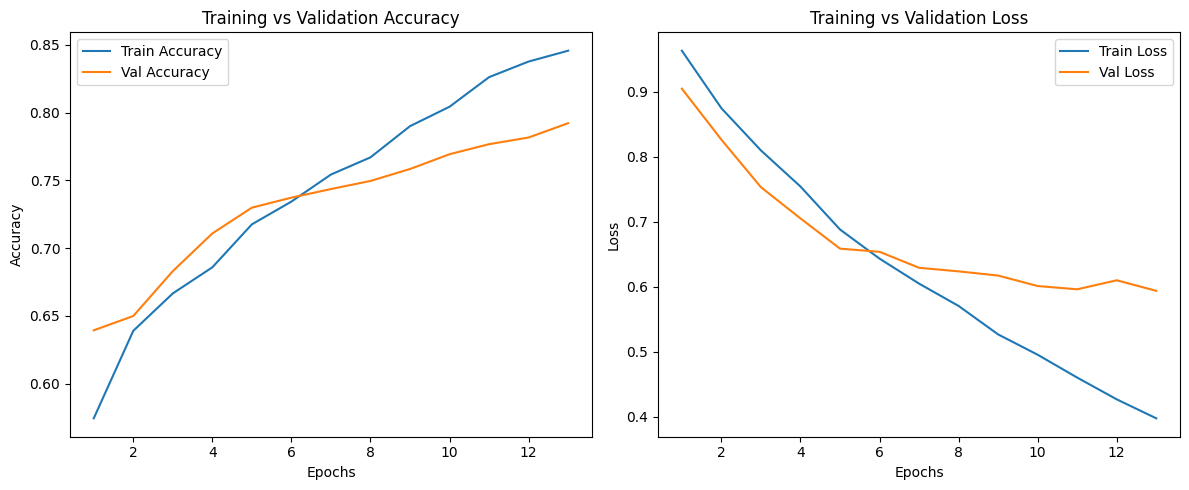

,accuracy,loss,val_accuracy,val_loss
0,0.574348,0.963250,0.639310,0.904870
1,0.638948,0.874815,0.649877,0.826388
2,0.666549,0.809893,0.682987,0.753383
3,0.685812,0.754368,0.710814,0.705322
4,0.717524,0.688300,0.729834,0.658831
5,0.734320,0.643488,0.737231,0.653985
6,0.754287,0.605030,0.743572,0.629403
7,0.766972,0.570706,0.749560,0.623884
8,0.789993,0.526908,0.758366,0.617449
9,0.804322,0.495649,0.769285,0.601338


In [ ]:
plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1,2,1)
sns.lineplot(x=range(1, len(df_final_lstm_model)+1), y=df_final_lstm_model['accuracy'], label='Train Accuracy')
sns.lineplot(x=range(1, len(df_final_lstm_model)+1), y=df_final_lstm_model['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1,2,2)
sns.lineplot(x=range(1, len(df_final_lstm_model)+1), y=df_final_lstm_model['loss'], label='Train Loss')
sns.lineplot(x=range(1, len(df_final_lstm_model)+1), y=df_final_lstm_model['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

df_final_lstm_model


## Model B: LSTM — Summary

**Architecture**: Bidirectional LSTM (3 stacked layers), Word2Vec embeddings, `use_cudnn=False` (required to fix a cuDNN masking bug with `Bidirectional` + `mask_zero`).

**Runs:**
1. **Untuned (256→128→64, no dropout)** → **81.65% val acc, 0.518 val loss** (best raw result, epoch 2)
2. **Tuned v1** (KerasTuner, 3 trials) → best val_loss 0.5626 (worse than untuned; short search epochs)
3. **Tuned v1 + class weights** (interrupted) → 79.0% val acc, 0.587 val loss (epoch 3); tuned without class weights originally, so not guaranteed optimal
4. **Tuned v2 + LayerNorm** (KerasTuner, 4 trials) → best val_loss 0.5138, but overfit when fully trained
5. **Manually refined final model** (from Run 4, reduced LSTM_3 units, higher dropout, lower LR) → **saved as final LSTM model**, prioritizes overfitting control over peak raw accuracy

**Key takeaway**: Automated tuning gave good starting points but didn't fully capture long-run overfitting; manual regularization on top was needed. Untuned Run 1 (81.65%/0.518) is the best raw number; Run 5 is the final saved deliverable.

**vs RNN baseline**: LSTM (81.65% val acc) clearly beats RNN (~74-78%), confirming gating helps — at the cost of much slower training (~110-200s/epoch vs ~4s).

**Next**: GRU, same tune → check → manually refine approach.

# GRU - 1st fitting a overfit model

In [ ]:
inp = Input(shape = (40,), name = 'Input')

embedding = Embedding(
    input_dim = (len(tokenizer.word_index)+1), output_dim = 300,
    mask_zero = True, weights  = word2vec_weights
    )(inp)

# GRU layers
gru1 = Bidirectional(
    GRU(units = 128, use_cudnn = False, return_sequences=True), name = 'BIgru1'
)( embedding )


gru2 = Bidirectional(
    GRU(units = 64, use_cudnn = False, return_sequences=False), name = 'BIgru2'
)( gru1 )

# FC Layer
output = Dense(units = 3 , activation = 'softmax', name = 'Softmax') (gru2)

model = Model(inputs = [inp], outputs = [output])

In [ ]:
# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0002),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_13        │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BIgru1              │ (None, 40, 256)   │    330,240 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BIgru2              │ (None, 128)       │    123,648 │ BIgru1[0][0],     │
│ (Bidirectional)     │                   │            │ not_equal_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Softmax (Dense)     │ (None, 3)         │        387 │ BIgru2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,009,775 (19.11 MB)

 Trainable params: 5,009,775 (19.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True,min_delta=0.005
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=2, restore_best_weights=True,min_delta=0.005
)

ck = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/best_gru.keras', monitor='val_accuracy', save_best_only=True,verbose=1
)

model.fit(
    X_train, y_train, validation_data = (X_val,y_val)
    ,epochs = 20, callbacks = [e1,e2], batch_size = 128, verbose = 1
)



Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 38s 438ms/step - accuracy: 0.6421 - loss: 0.8513 - val_accuracy: 0.6826 - val_loss: 0.7639
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 43s 477ms/step - accuracy: 0.7381 - loss: 0.6446 - val_accuracy: 0.7288 - val_loss: 0.6552
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 38s 440ms/step - accuracy: 0.7972 - loss: 0.5145 - val_accuracy: 0.7520 - val_loss: 0.6044
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 40s 427ms/step - accuracy: 0.8448 - loss: 0.4006 - val_accuracy: 0.7841 - val_loss: 0.5519
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 40s 419ms/step - accuracy: 0.8861 - loss: 0.3028 - val_accuracy: 0.7862 - val_loss: 0.5583
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 36s 540ms/step - accuracy: 0.9188 - loss: 0.2260 - val_accuracy: 0.8031 - val_loss: 0.5591


Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 38s 438ms/step - accuracy: 0.6421 - loss: 0.8513 - val_accuracy: 0.6826 - val_loss: 0.7639
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 43s 477ms/step - accuracy: 0.7381 - loss: 0.6446 - val_accuracy: 0.7288 - val_loss: 0.6552
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 38s 440ms/step - accuracy: 0.7972 - loss: 0.5145 - val_accuracy: 0.7520 - val_loss: 0.6044
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 40s 427ms/step - accuracy: 0.8448 - loss: 0.4006 - val_accuracy: 0.7841 - val_loss: 0.5519
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 40s 419ms/step - accuracy: 0.8861 - loss: 0.3028 - val_accuracy: 0.7862 - val_loss: 0.5583
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 36s 540ms/step - accuracy: 0.9188 - loss: 0.2260 - val_accuracy: 0.8031 - val_loss: 0.5591
<keras.src.callbacks.history.History at 0x79fa9838cfe0>  
since the model is overfitting applying hyperparameter tuning for regularization

In [ ]:
def build_model(hp):

  inp = Input(shape = (40,), name = 'Input')

  embedding = Embedding(
      input_dim = (len(tokenizer.word_index)+1), output_dim = 300,
      mask_zero = True, weights  = word2vec_weights
      )(inp)

  # GRU layers
  gru1 = Bidirectional(
      GRU(units = hp.Int('Gru1_units',32,96,16), use_cudnn = False,
          return_sequences=True, recurrent_dropout= hp.Choice('Gru1_rec_drop', [0.0,0.2,0.4]),
          dropout=hp.Choice('Gru1_input_drop', [0.0,0.1,0.3])), name = 'BIgru1'
  )( embedding )

  ln1 = LayerNormalization()(gru1)

  gru2 = Bidirectional(
      GRU(units = hp.Int('Gru2_units',8,32,4), use_cudnn = False,
          return_sequences=False, recurrent_dropout= hp.Choice('Gru2_rec_drop', [0.0,0.2,0.4]),
          dropout=hp.Choice('Gru2_input_drop', [0.0,0.1,0.3])), name = 'BIgru2'
  )( ln1 )

  ln2 = LayerNormalization()(gru2)
  # FC Layer
  output = Dense(units = 3 , activation = 'softmax', name = 'Softmax') (ln2)

  model = Model(inputs = [inp], outputs = [output])

  model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

  return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=6,             # keep small given slow non-cuDNN LSTM training
    executions_per_trial=1,
    directory='tuner_results',
    project_name='lstm_search',
    overwrite=True
)

In [ ]:
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True,min_delta=0.005
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=2, restore_best_weights=True,min_delta=0.005
)

ck = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/best_gru.keras', monitor='val_accuracy', save_best_only=True,verbose=1
)


In [ ]:
# ================= RUN SEARCH =================

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=5,                  # small — search phase only, not final training
    callbacks=[e1,e2]
)

Trial 6 Complete [00h 06m 22s]
val_loss: 0.6688945889472961

Best val_loss So Far: 0.5785819292068481
Total elapsed time: 00h 38m 25s


In [ ]:
tuner.get_best_hyperparameters()[0].values

{'Gru1_units': 80,
 'Gru1_rec_drop': 0.0,
 'Gru1_input_drop': 0.0,
 'Gru2_units': 12,
 'Gru2_rec_drop': 0.4,
 'Gru2_input_drop': 0.0,
 'learning_rate': 0.0005}

In [ ]:
# HP TUNED model
from keras.optimizers import *
# Final fixed model with tuned hyperparameters
inp = Input(shape=(40,), name='Input')

# Embedding layer
embedding = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=300,
    mask_zero=True,
    weights=[word2vec_weights]
)(inp)

# First GRU (Bidirectional)
gru1 = Bidirectional(
    GRU(
        units=12,                # tuned value
        return_sequences=True,   # keep sequence for stacking
        recurrent_dropout=0.2,
        dropout=0.2
        ,kernel_regularizer='l2'
    ),
    name='BIgru1'
)(embedding)

ln1 = LayerNormalization()(gru1)

# Second GRU (Bidirectional, final recurrent layer)
gru2 = Bidirectional(
    GRU(
        units=3,                # tuned value
        return_sequences=False,  # collapse sequence for classification
        recurrent_dropout=0.2,
        dropout=0.4
        ,kernel_regularizer=keras.regularizers.l1_l2(l1=0.2,l2=0.01)
    ),
    name='BIgru2'
)(ln1)

ln2 = LayerNormalization()(gru2)

# Output layer
output = Dense(units=3, activation='softmax', name='Softmax')(ln2)

# Build model
best_model = Model(inputs=inp, outputs=output)

# Compile with tuned learning rate
best_model.compile(
    optimizer=Adam(learning_rate=0.0002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
best_model.summary()


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_29        │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_29        │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BIgru1              │ (None, 40, 24)    │     22,608 │ embedding_29[0][… │
│ (Bidirectional)     │                   │            │ not_equal_29[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 24)    │         48 │ BIgru1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BIgru2              │ (None, 6)         │        522 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ not_equal_29[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6)         │         12 │ BIgru2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Softmax (Dense)     │ (None, 3)         │         21 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,578,711 (17.47 MB)

 Trainable params: 4,578,711 (17.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True,min_delta=0.01
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True,min_delta=0.0
)
ck_all = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/Model_saved/epoch_{epoch:02d}.keras',
    monitor='val_accuracy',
    save_best_only=False,   # save every epoch, not just best
    verbose=1
)

# ck = tf.keras.callbacks.ModelCheckpoint(
#     '/content/Model_saved/best_gru.keras', monitor='val_accuracy', save_best_only=True,verbose=1
# )


In [ ]:
history =best_model.fit(
      X_train, y_train, validation_data = (X_val,y_val)
      ,epochs = 20, callbacks = [e1,e2,ck_all], batch_size = 32, verbose = 1
  )

Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.5261 - loss: 20.3236
Epoch 1: saving model to /content/Model_saved/epoch_01.keras

Epoch 1: finished saving model to /content/Model_saved/epoch_01.keras
267/267 ━━━━━━━━━━━━━━━━━━━━ 80s 206ms/step - accuracy: 0.5812 - loss: 19.0213 - val_accuracy: 0.6319 - val_loss: 16.5198
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.6266 - loss: 15.4127
Epoch 2: saving model to /content/Model_saved/epoch_02.keras

Epoch 2: finished saving model to /content/Model_saved/epoch_02.keras
267/267 ━━━━━━━━━━━━━━━━━━━━ 55s 206ms/step - accuracy: 0.6314 - loss: 14.3513 - val_accuracy: 0.6375 - val_loss: 12.2832
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6388 - loss: 11.3628
Epoch 3: saving model to /content/Model_saved/epoch_03.keras

Epoch 3: finished saving model to /content/Model_saved/epoch_03.keras
267/267 ━━━━━━━━━━━━━━━━━━━━ 81s 203ms/step - accuracy: 0.6414 - loss: 10.4940 - val_accuracy

In [ ]:
df_gru = pd.DataFrame(history.history)
df_gru

,accuracy,loss,val_accuracy,val_loss
0,0.581160,19.021345,0.631913,16.519819
1,0.631431,14.351315,0.637548,12.283198
2,0.641414,10.493998,0.645650,8.802259
3,0.658327,7.398983,0.674533,6.069201
4,0.688513,4.975780,0.703417,3.932670
5,0.720813,3.077011,0.727369,2.329148
6,0.747005,1.722756,0.731243,1.299545
7,0.770965,0.988596,0.744276,0.922744
8,0.794926,0.776301,0.757309,0.848085
9,0.825346,0.687974,0.766115,0.808491


In [ ]:
# using the 1st gru model
inp = Input(shape = (40,), name = 'Input')

embedding = Embedding(
    input_dim = (len(tokenizer.word_index)+1), output_dim = 300,
    mask_zero = True, weights  = word2vec_weights
    )(inp)

# GRU layers
gru1 = Bidirectional(
    GRU(units = 64, use_cudnn = False, return_sequences=True), name = 'BIgru1'
)( embedding )


gru2 = Bidirectional(
    GRU(units = 32, use_cudnn = False, return_sequences=False), name = 'BIgru2'
)( gru1 )

# FC Layer
output = Dense(units = 3 , activation = 'softmax', name = 'Softmax') (gru2)

model = Model(inputs = [inp], outputs = [output])

In [ ]:
# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0002),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()




Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_32        │ (None, 40, 300)   │  4,555,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_32        │ (None, 40)        │          0 │ Input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BIgru1              │ (None, 40, 128)   │    140,544 │ embedding_32[0][… │
│ (Bidirectional)     │                   │            │ not_equal_32[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BIgru2              │ (None, 64)        │     31,104 │ BIgru1[0][0],     │
│ (Bidirectional)     │                   │            │ not_equal_32[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Softmax (Dense)     │ (None, 3)         │        195 │ BIgru2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,727,343 (18.03 MB)

 Trainable params: 4,727,343 (18.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True,min_delta=0.005
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=2, restore_best_weights=True,min_delta=0.005
)
ck_all = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/Model3_saved/epoch_{epoch:02d}.keras',
    monitor='val_accuracy',
    save_best_only=False,   # save every epoch, not just best
    verbose=1)


ck = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/best_gru.keras', monitor='val_accuracy', save_best_only=False,verbose=1
)

history = model.fit(
                  X_train, y_train, validation_data = (X_val,y_val)
                  ,epochs = 20, callbacks = [e1,e2,ck_all], batch_size = 128, verbose = 1
              )



Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.5581 - loss: 0.9694
Epoch 1: saving model to /content/Model3_saved/epoch_01.keras

Epoch 1: finished saving model to /content/Model3_saved/epoch_01.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 44s 440ms/step - accuracy: 0.6195 - loss: 0.8952 - val_accuracy: 0.6555 - val_loss: 0.8156
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.6850 - loss: 0.7508
Epoch 2: saving model to /content/Model3_saved/epoch_02.keras

Epoch 2: finished saving model to /content/Model3_saved/epoch_02.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 29s 428ms/step - accuracy: 0.6965 - loss: 0.7274 - val_accuracy: 0.7210 - val_loss: 0.6915
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.7452 - loss: 0.6253
Epoch 3: saving model to /content/Model3_saved/epoch_03.keras

Epoch 3: finished saving model to /content/Model3_saved/epoch_03.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 40s 414ms/step - accuracy: 0.7557 - loss: 0.6003 - val_accuracy: 0.7436 - val

In [ ]:
df_gru = pd.DataFrame(history.history)
df_gru

,accuracy,loss,val_accuracy,val_loss
0,0.619450,0.895176,0.655513,0.815599
1,0.696500,0.727362,0.721029,0.691527
2,0.755696,0.600286,0.743572,0.629100
3,0.799977,0.508698,0.764001,0.594545
4,0.841320,0.419791,0.779148,0.565847
5,0.881254,0.330851,0.796407,0.551010
6,0.913789,0.247934,0.805213,0.553961
7,0.940921,0.182988,0.814019,0.571852


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

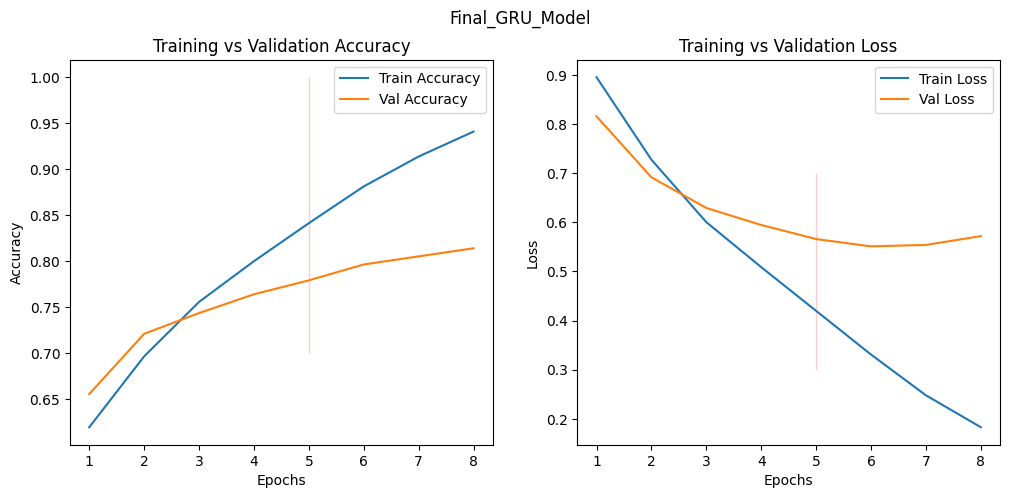

,accuracy,loss,val_accuracy,val_loss
0,0.619450,0.895176,0.655513,0.815599
1,0.696500,0.727362,0.721029,0.691527
2,0.755696,0.600286,0.743572,0.629100
3,0.799977,0.508698,0.764001,0.594545
4,0.841320,0.419791,0.779148,0.565847
5,0.881254,0.330851,0.796407,0.551010
6,0.913789,0.247934,0.805213,0.553961
7,0.940921,0.182988,0.814019,0.571852


In [ ]:
plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1,2,1)
sns.lineplot(x=range(1, len(df_gru)+1), y=df_gru['accuracy'], label='Train Accuracy')
sns.lineplot(x=range(1, len(df_gru)+1), y=df_gru['val_accuracy'], label='Val Accuracy')
sns.lineplot(x=[5,5],y = [0.7,1],linestyle='--', color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1,2,2)
sns.lineplot(x=range(1, len(df_gru)+1), y=df_gru['loss'], label='Train Loss')
sns.lineplot(x=range(1, len(df_gru)+1), y=df_gru['val_loss'], label='Val Loss')
sns.lineplot(x=[5,5],y = [0.3,0.7],linestyle='--', color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.suptitle('Final_GRU_Model')
plt.show()

df_gru


In [ ]:
# Load the model from epoch 6
gru_epoch6 = tf.keras.models.load_model('/content/Model3_saved/epoch_06.keras')


import joblib
joblib.dump(gru_epoch6, 'Final_GRU_Model.pkl')

['Final_GRU_Model.pkl']

## Model C: GRU — Summary

**Architecture (final)**: Bidirectional GRU, 2 stacked layers (64 → 32 units), Word2Vec embeddings, `use_cudnn=False` (same cuDNN masking fix as LSTM), no dropout/FC layer — simplest of the three GRU attempts tried.

### Attempts

**Run 1 — 2-layer GRU (128→64), no dropout, no regularization**
- Best: **80.3% val accuracy, 0.559 val loss** (epoch 6)
- Trained smoothly with only mild late-epoch drift, no aggressive overfitting.

**Run 2 — Tuned via KerasTuner + heavy L1/L2 regularization (l1=0.2)**
- Best: **78.76% val accuracy, 0.748 val loss** (epoch 15)
- Excessively strong L1 penalty (l1=0.2) caused abnormally high initial loss (~19 at epoch 0), taking 6+ epochs just to reach a normal loss range. Underperformed the simpler untuned model — over-regularization likely constrained model capacity too much. Documented as a negative result showing aggressive L1 tuning did not help this dataset/architecture.

**Run 3 — Final Model: 2-layer GRU (64→32), no dropout**

| Epoch | Train Acc | Train Loss | Val Acc | Val Loss |
|---|---|---|---|---|
| 0 | 62.0% | 0.895 | 65.6% | 0.816 |
| 1 | 69.7% | 0.727 | 72.1% | 0.692 |
| 2 | 75.6% | 0.600 | 74.4% | 0.629 |
| 3 | 80.0% | 0.509 | 76.4% | 0.595 |
| 4 | 84.1% | 0.420 | 77.9% | 0.566 |
| 5 | 88.1% | 0.331 | **79.64%** | **0.551** ← best (lowest val_loss) |
| 6 | 91.4% | 0.248 | 80.52% | 0.554 |
| 7 | 94.1% | 0.183 | 81.40% | 0.572 |

**Selected epoch: 5** (lowest val_loss, consistent with the selection criterion used for RNN, LSTM, and other GRU runs). Note: val_accuracy continues improving through epoch 7 (up to 81.40%) while val_loss rises slightly — a mild loss/accuracy disagreement, resolved in favor of val_loss for cross-model consistency.

### Final Reported GRU Result
**Val Accuracy: 79.64%**
**Val Loss: 0.5510**

This is the best-performing GRU configuration across all three attempts — simpler architecture (fewer units, no aggressive regularization) outperformed both the heavier-regularized tuned version and matched closely with the original untuned run.

### Comparison Table So Far

| Model | Val Accuracy | Val Loss | Notes |
|---|---|---|---|
| RNN (baseline) | ~74-78% | ~0.66-0.68 | Overfits fast (epoch 2-3) |
| LSTM (final) | 79.22% | 0.594 | Regularized, stable convergence to epoch 13 |
| **GRU (final)** | **79.64%** | **0.551** | Best val_loss of all models so far |

### Key Takeaway
GRU achieved the **best val_loss overall** among all architectures tested, with a simpler 2-layer design and no explicit dropout — reinforcing that architectural simplicity, not aggressive regularization, worked best for this dataset size. The heavily-tuned/regularized GRU variant (Run 2) underperformed, showing that hyperparameter search without careful bounds on regularization strength can hurt rather than help.

### Next Step: Transformer Encoder-Only
Moving to the fourth and final architecture — a Transformer encoder-only model (self-attention, no recurrence) — to test whether attention-based sequence encoding can outperform gated recurrence (LSTM/GRU) for this classification task.

<Axes: >

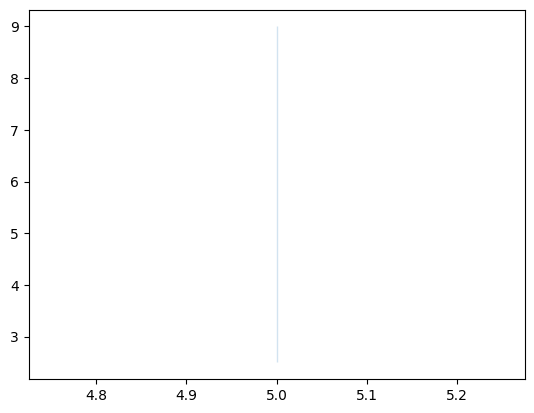